## Setup and Imports

In [1]:
import sys
import os
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

project_root = Path().resolve().parents[1]
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from utils.helpers import set_style, save_figure, start_logging
set_style()
log = start_logging(project_root, '04_01_churn_labelling')

print('All imports successful')

Logging started — 2026-04-27 12:41:27.555242
Log: /Users/seleteakpotosu-nartey/Downloads/Data Stuff/Gamezone/gamezone-analytics/logs/04_01_churn_labelling.txt
All imports successful



## Load Data

In [2]:
processed_path = project_root / 'data' / 'processed'

# Load clean master dataset - one row per order
df_raw = pd.read_csv(processed_path / 'orders_clean_master.csv')
df_raw['PURCHASE_TS'] = pd.to_datetime(df_raw['PURCHASE_TS'], errors='coerce')
df = df_raw.copy()

# Load RFM segments from Project 02 - we use these as covariates
rfm_raw = pd.read_csv(processed_path / 'rfm_segments.csv')
rfm = rfm_raw.copy()

# Load channel ROI summary for channel covariate
orders_seg_raw = pd.read_csv(processed_path / 'orders_with_segments.csv')
orders_seg_raw['PURCHASE_TS'] = pd.to_datetime(orders_seg_raw['PURCHASE_TS'], errors='coerce')
orders_seg = orders_seg_raw.copy()

print(f'Orders loaded: {len(df):,}')
print(f'RFM customers: {len(rfm):,}')
print(f'Date range: {df["PURCHASE_TS"].min().date()} to {df["PURCHASE_TS"].max().date()}')

log(f'Orders loaded: {len(df):,}')
log(f'RFM customers: {len(rfm):,}')
log(f'Date range: {df["PURCHASE_TS"].min().date()} to {df["PURCHASE_TS"].max().date()}')

Orders loaded: 21,719
RFM customers: 19,723
Date range: 2019-01-01 to 2021-02-28
Orders loaded: 21,719
RFM customers: 19,723
Date range: 2019-01-01 to 2021-02-28



## Define the Observation Window



In [3]:
# Observation window
# We exclude $0 price orders and null dates from the timeline
df_valid = df[(df['USD_PRICE'] > 0) & (df['PURCHASE_TS'].notna())].copy()

OBS_START = df_valid['PURCHASE_TS'].min()
OBS_END   = df_valid['PURCHASE_TS'].max()
OBS_DAYS  = (OBS_END - OBS_START).days

print(f'Observation window start: {OBS_START.date()}')
print(f'Observation window end:   {OBS_END.date()}')
print(f'Total observation days:   {OBS_DAYS}')
print(f'Valid orders in window:   {len(df_valid):,}')

log(f'Observation window: {OBS_START.date()} to {OBS_END.date()} ({OBS_DAYS} days)')
log(f'Valid orders in window:   {len(df_valid):,}')

Observation window start: 2019-01-01
Observation window end:   2021-02-28
Total observation days:   789
Valid orders in window:   14,954
Observation window: 2019-01-01 to 2021-02-28 (789 days)
Valid orders in window:   14,954


In [4]:
# Build customer-level timeline
# For each customer we need:
#   first_purchase: entry into observation window
#   last_purchase:  most recent purchase (used to calculate recency)
#   total_orders:   how many times they purchased
#   total_spend:    total revenue from this customer
#   tenure_days:    days from first purchase to observation end

customer_timeline = df_valid.groupby('USER_ID').agg(
    first_purchase = ('PURCHASE_TS', 'min'),
    last_purchase  = ('PURCHASE_TS', 'max'),
    total_orders   = ('ORDER_ID',    'count'),
    total_spend    = ('USD_PRICE',   'sum')
).reset_index()

# Tenure = days from first purchase to end of observation window
# This is the maximum time we could have observed this customer
customer_timeline['tenure_days'] = (
    OBS_END - customer_timeline['first_purchase']
).dt.days

# Recency = days since last purchase
customer_timeline['recency_days'] = (
    OBS_END - customer_timeline['last_purchase']
).dt.days

print(f'Customer timeline built: {len(customer_timeline):,} customers')
print()
print('Tenure distribution (days from first purchase to window end):')
print(customer_timeline['tenure_days'].describe().round(0))
print()
print('Recency distribution (days since last purchase):')
print(customer_timeline['recency_days'].describe().round(0))

log(f'Customer timeline built: {len(customer_timeline):,} customers')
log()
log('Tenure distribution (days from first purchase to window end):')
log(customer_timeline['tenure_days'].describe().round(0)) # pyright: ignore[reportArgumentType]
log()
log('Recency distribution (days since last purchase):')
log(customer_timeline['recency_days'].describe().round(0)) # pyright: ignore[reportArgumentType]

Customer timeline built: 13,778 customers

Tenure distribution (days from first purchase to window end):
count    13778.0
mean       337.0
std        202.0
min          0.0
25%        170.0
50%        297.0
75%        488.0
max        789.0
Name: tenure_days, dtype: float64

Recency distribution (days since last purchase):
count    13778.0
mean       334.0
std        201.0
min          0.0
25%        169.0
50%        295.0
75%        484.0
max        789.0
Name: recency_days, dtype: float64
Customer timeline built: 13,778 customers

Tenure distribution (days from first purchase to window end):
count    13778.0
mean       337.0
std        202.0
min          0.0
25%        170.0
50%        297.0
75%        488.0
max        789.0
Name: tenure_days, dtype: float64

Recency distribution (days since last purchase):
count    13778.0
mean       334.0
std        201.0
min          0.0
25%        169.0
50%        295.0
75%        484.0
max        789.0
Name: recency_days, dtype: float64



##  Data-Driven Churn Threshold


In [5]:
# Calculate inter-purchase gaps for repeat buyers
repeat_buyers = df_valid[df_valid['USER_ID'].isin(
    customer_timeline[customer_timeline['total_orders'] > 1]['USER_ID']
)].copy()

repeat_buyers = repeat_buyers.sort_values(['USER_ID', 'PURCHASE_TS'])
repeat_buyers['prev_purchase'] = repeat_buyers.groupby('USER_ID')['PURCHASE_TS'].shift(1)
repeat_buyers['gap_days'] = (
    repeat_buyers['PURCHASE_TS'] - repeat_buyers['prev_purchase']
).dt.days

gaps = repeat_buyers['gap_days'].dropna()

print(f'Repeat buyers: {repeat_buyers["USER_ID"].nunique():,}')
print(f'Inter-purchase gaps observed: {len(gaps):,}')
print()
print('Gap distribution (days between consecutive purchases):')
print(gaps.describe().round(0))
print()

# Set churn threshold at 90th percentile of gaps with 180-day floor
p90_gap = gaps.quantile(0.90)
CHURN_THRESHOLD = max(int(p90_gap), 180)

print(f'90th percentile of inter-purchase gaps: {p90_gap:.0f} days')
print(f'Churn threshold applied:                {CHURN_THRESHOLD} days')

Repeat buyers: 1,108
Inter-purchase gaps observed: 1,176

Gap distribution (days between consecutive purchases):
count    1176.0
mean       24.0
std        77.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max       684.0
Name: gap_days, dtype: float64

90th percentile of inter-purchase gaps: 60 days
Churn threshold applied:                180 days


In [6]:
# Apply churn label
# A customer is churned if their recency exceeds the threshold
# AND they had enough tenure to potentially churn
# (customers who only joined recently cannot have churned yet)

customer_timeline['churned'] = (
    customer_timeline['recency_days'] >= CHURN_THRESHOLD
).astype(int)

# Survival duration:
# For churned customers: days from first purchase to last purchase
# For active customers:  days from first purchase to observation end (censored)
# This is the 'T' variable in survival analysis
customer_timeline['duration'] = np.where(
    customer_timeline['churned'] == 1,
    (customer_timeline['last_purchase'] - customer_timeline['first_purchase']).dt.days,
    customer_timeline['tenure_days']
)

# Ensure minimum duration of 1 day to avoid zero-duration issues
customer_timeline['duration'] = customer_timeline['duration'].clip(lower=1)

churn_rate = customer_timeline['churned'].mean() * 100
n_churned  = customer_timeline['churned'].sum()
n_active   = len(customer_timeline) - n_churned

print(f'Churn threshold: {CHURN_THRESHOLD} days')
print(f'Churned customers: {n_churned:,} ({churn_rate:.1f}%)')
print(f'Active customers:  {n_active:,} ({100-churn_rate:.1f}%)')
print()
print('Duration statistics (days from first to last purchase or window end):')
print(customer_timeline['duration'].describe().round(0))

Churn threshold: 180 days
Churned customers: 9,993 (72.5%)
Active customers:  3,785 (27.5%)

Duration statistics (days from first to last purchase or window end):
count    13778.0
mean        34.0
std         60.0
min          1.0
25%          1.0
50%          1.0
75%         66.0
max        747.0
Name: duration, dtype: float64



## Add Covariate Features


In [7]:
# Get primary channel and region per customer
# Same approach as Notebook 3/4 in Project 02 - most frequent value
def most_frequent(x):
    counts = x.value_counts()
    return counts.index[0] if len(counts) > 0 else np.nan

customer_covariates = df_valid.groupby('USER_ID').agg(
    primary_channel = ('MARKETING_CHANNEL', most_frequent),
    primary_region  = ('REGION',            most_frequent),
    primary_product = ('PRODUCT_NAME',      most_frequent),
    avg_order_value = ('USD_PRICE',         'mean')
).reset_index()

# Merge with RFM segments
customer_covariates = customer_covariates.merge(
    rfm[['USER_ID', 'segment', 'R_score', 'F_score', 'M_score', 'RFM_score']],
    on='USER_ID', how='left'
)

print(f'Covariates built for {len(customer_covariates):,} customers')
print()
print('Channel distribution:')
print(customer_covariates['primary_channel'].value_counts())
print()
print('Region distribution:')
print(customer_covariates['primary_region'].value_counts())
print()
print('Segment distribution:')
print(customer_covariates['segment'].value_counts())

Covariates built for 13,778 customers

Channel distribution:
primary_channel
direct          11044
email            1995
affiliate         455
social media      210
unknown            18
Name: count, dtype: int64

Region distribution:
primary_region
Americas    7102
EMEA        4251
APAC        1610
LATAM        812
Other          3
Name: count, dtype: int64

Segment distribution:
segment
At Risk            8591
Lapsed             3020
Champions          1169
Loyal Customers     998
Name: count, dtype: int64


In [8]:
# Merge timeline with covariates
survival_df = customer_timeline.merge(customer_covariates, on='USER_ID', how='left')

# Flag high-ticket buyers - customers whose primary product is a high-ticket item
high_ticket_products = [
    'Sony PlayStation 5 Bundle',
    'Lenovo IdeaPad Gaming 3',
    'Acer Nitro V Gaming Laptop'
]
survival_df['is_high_ticket_buyer'] = (
    survival_df['primary_product'].isin(high_ticket_products)
).astype(int)

# Encode channel and region as binary flags for Cox model
# Cox model needs numeric covariates - we create dummies
survival_df['is_direct']    = (survival_df['primary_channel'] == 'direct').astype(int)
survival_df['is_email']     = (survival_df['primary_channel'] == 'email').astype(int)
survival_df['is_affiliate'] = (survival_df['primary_channel'] == 'affiliate').astype(int)
survival_df['is_apac']      = (survival_df['primary_region'] == 'APAC').astype(int)
survival_df['is_emea']      = (survival_df['primary_region'] == 'EMEA').astype(int)
survival_df['is_latam']     = (survival_df['primary_region'] == 'LATAM').astype(int)

print(f'Survival dataset: {len(survival_df):,} rows, {len(survival_df.columns)} columns')
print(f'Null values per key column:')
key_cols = ['duration', 'churned', 'segment', 'primary_channel',
            'primary_region', 'RFM_score', 'avg_order_value']
for col in key_cols:
    if col in survival_df.columns:
        print(f'  {col}: {survival_df[col].isna().sum()}')

Survival dataset: 13,778 rows, 25 columns
Null values per key column:
  duration: 0
  churned: 0
  segment: 0
  primary_channel: 56
  primary_region: 0
  RFM_score: 0
  avg_order_value: 0


## Visualisations

Figure saved → reports/figures/04_01_recency_distribution.png


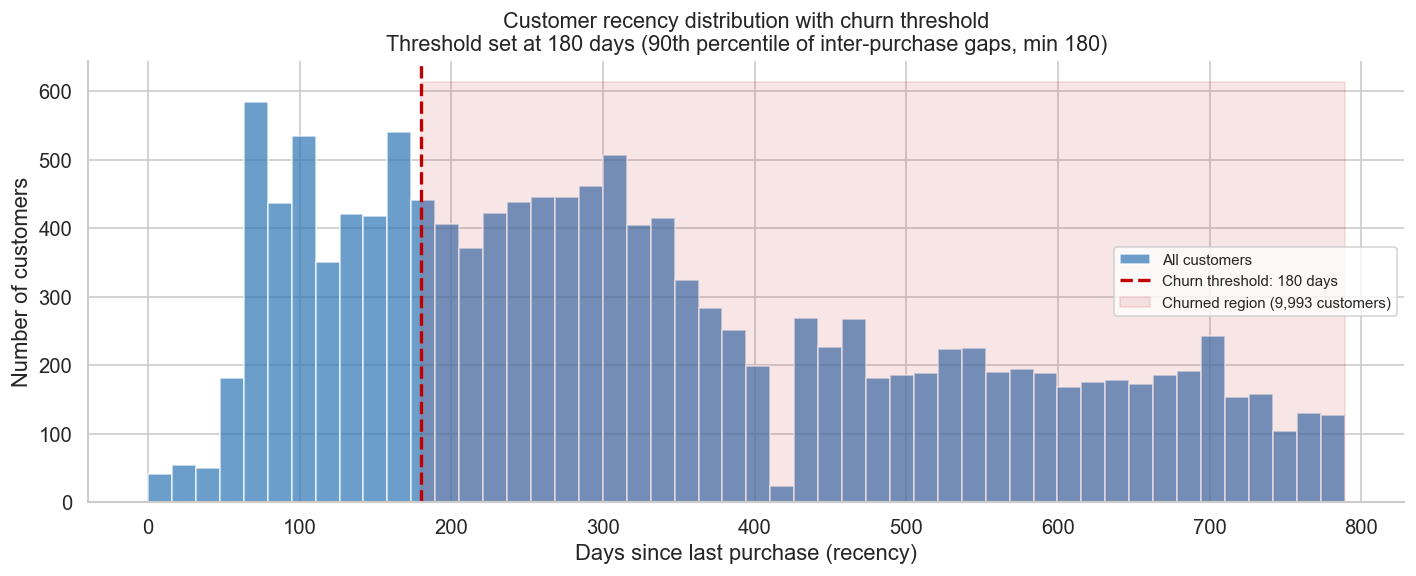

In [9]:
# Chart 1: Recency distribution with churn threshold
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(customer_timeline['recency_days'], bins=50,
        color='#2E75B6', alpha=0.7, edgecolor='white', label='All customers')
ax.axvline(CHURN_THRESHOLD, color='#C00000', linestyle='--',
           linewidth=2, label=f'Churn threshold: {CHURN_THRESHOLD} days')

churned_count = (customer_timeline['recency_days'] >= CHURN_THRESHOLD).sum()
ax.fill_betweenx(
    [0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 3000],
    CHURN_THRESHOLD, customer_timeline['recency_days'].max(),
    alpha=0.1, color='#C00000', label=f'Churned region ({churned_count:,} customers)'
)

ax.set_title('Customer recency distribution with churn threshold\n'
             f'Threshold set at {CHURN_THRESHOLD} days (90th percentile of inter-purchase gaps, min 180)',
             fontsize=13, fontweight='medium')
ax.set_xlabel('Days since last purchase (recency)')
ax.set_ylabel('Number of customers')
ax.legend(fontsize=9)

save_figure(fig, '04_01_recency_distribution.png')
plt.show()

Figure saved → reports/figures/04_01_churn_rate_by_segment.png


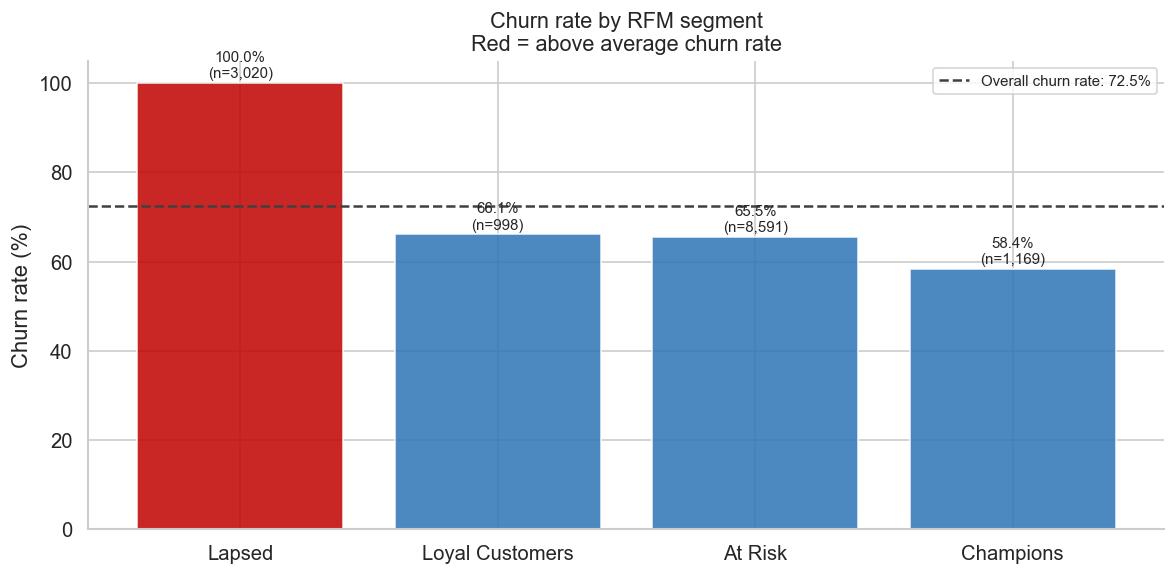

In [10]:
# Chart 2: Churn rate by segment
seg_churn = survival_df.groupby('segment').agg(
    total    = ('USER_ID',  'count'),
    churned  = ('churned',  'sum')
).assign(churn_rate=lambda x: x['churned'] / x['total'] * 100)
seg_churn = seg_churn.sort_values('churn_rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#C00000' if r > churn_rate else '#2E75B6'
          for r in seg_churn['churn_rate']]
bars = ax.bar(seg_churn.index, seg_churn['churn_rate'],
              color=colors, alpha=0.85)
ax.axhline(churn_rate, color='#404040', linestyle='--',
           linewidth=1.5, label=f'Overall churn rate: {churn_rate:.1f}%')

for bar, val, n in zip(bars, seg_churn['churn_rate'], seg_churn['total']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%\n(n={n:,})', ha='center', va='bottom', fontsize=9)

ax.set_title('Churn rate by RFM segment\n'
             'Red = above average churn rate',
             fontsize=13, fontweight='medium')
ax.set_ylabel('Churn rate (%)')
ax.legend(fontsize=9)

save_figure(fig, '04_01_churn_rate_by_segment.png')
plt.show()

Figure saved → reports/figures/04_01_duration_distribution.png


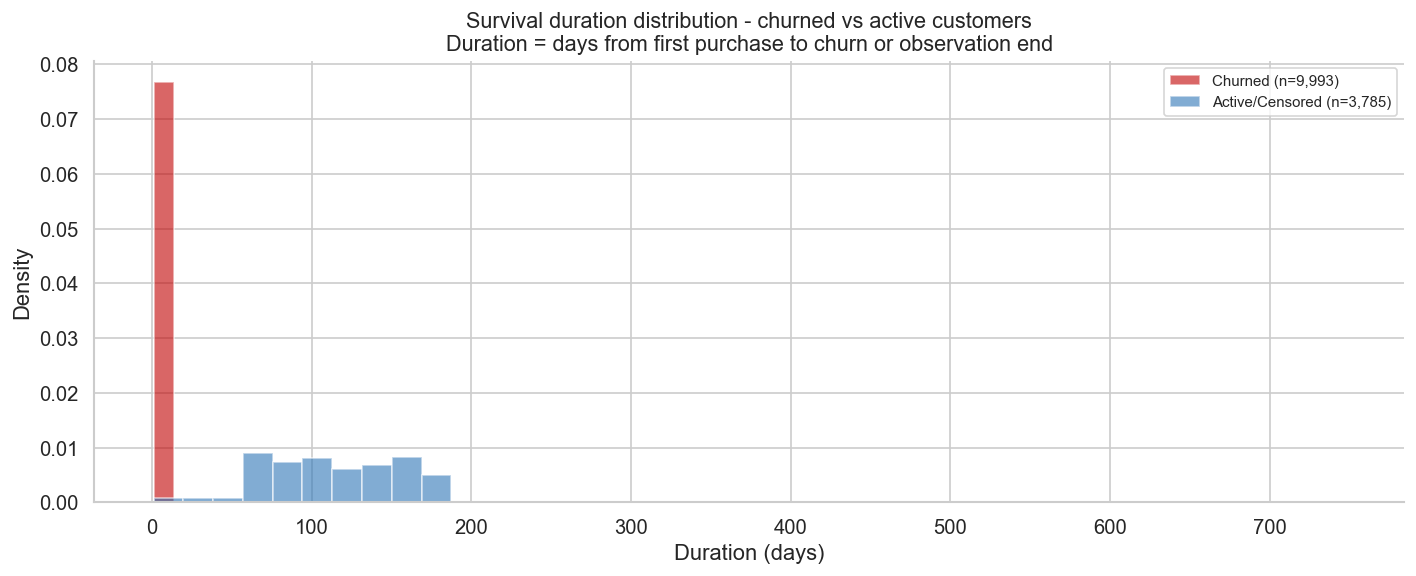

In [11]:
# Chart 3: Duration distribution - churned vs active
fig, ax = plt.subplots(figsize=(12, 5))

churned_dur = survival_df[survival_df['churned'] == 1]['duration']
active_dur  = survival_df[survival_df['churned'] == 0]['duration']

ax.hist(churned_dur, bins=40, alpha=0.6, color='#C00000',
        label=f'Churned (n={len(churned_dur):,})', density=True)
ax.hist(active_dur, bins=40, alpha=0.6, color='#2E75B6',
        label=f'Active/Censored (n={len(active_dur):,})', density=True)

ax.set_title('Survival duration distribution - churned vs active customers\n'
             'Duration = days from first purchase to churn or observation end',
             fontsize=13, fontweight='medium')
ax.set_xlabel('Duration (days)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

save_figure(fig, '04_01_duration_distribution.png')
plt.show()

Figure saved → reports/figures/04_01_churn_rate_by_channel.png


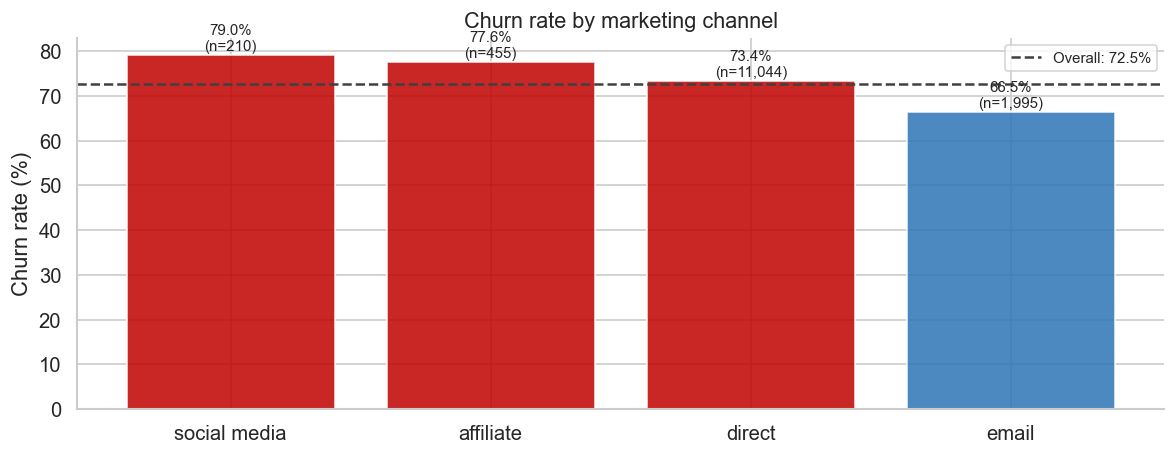

In [12]:
# Chart 4: Churn rate by channel
channel_churn = survival_df.groupby('primary_channel').agg(
    total   = ('USER_ID', 'count'),
    churned = ('churned', 'sum')
).assign(churn_rate=lambda x: x['churned'] / x['total'] * 100)
channel_churn = channel_churn[
    channel_churn['total'] >= 50
].sort_values('churn_rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))

colors = ['#C00000' if r > churn_rate else '#2E75B6'
          for r in channel_churn['churn_rate']]
bars = ax.bar(channel_churn.index, channel_churn['churn_rate'],
              color=colors, alpha=0.85)
ax.axhline(churn_rate, color='#404040', linestyle='--',
           linewidth=1.5, label=f'Overall: {churn_rate:.1f}%')

for bar, val, n in zip(bars, channel_churn['churn_rate'], channel_churn['total']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%\n(n={n:,})', ha='center', va='bottom', fontsize=9)

ax.set_title('Churn rate by marketing channel',
             fontsize=13, fontweight='medium')
ax.set_ylabel('Churn rate (%)')
ax.legend(fontsize=9)

save_figure(fig, '04_01_churn_rate_by_channel.png')
plt.show()

## Findings

In [ ]:
highest_churn_seg  = seg_churn['churn_rate'].idxmax()
lowest_churn_seg   = seg_churn['churn_rate'].idxmin()
highest_churn_ch   = channel_churn['churn_rate'].idxmax()
lowest_churn_ch    = channel_churn['churn_rate'].idxmin()

print('Notebook 1 Findings - Churn Definition and Labelling')
print()
print('Churn definition')
print(f'  Threshold: {CHURN_THRESHOLD} days since last purchase')
print(f'  Basis: 90th percentile of inter-purchase gaps among repeat buyers')
print(f'  Floor applied: 180 days minimum to avoid labelling normal gaps as churn')
print()
print('Observation window')
print(f'  Start: {OBS_START.date()}')
print(f'  End:   {OBS_END.date()}')
print(f'  Total: {OBS_DAYS} days')
print()
print('Churn summary')
print(f'  Total customers:   {len(survival_df):,}')
print(f'  Churned:           {n_churned:,} ({churn_rate:.1f}%)')
print(f'  Active (censored): {n_active:,} ({100-churn_rate:.1f}%)')
print()
print('Finding 1 - Churn is heavily concentrated in lower RFM segments')
print(f'  {highest_churn_seg} has the highest churn rate: '
      f'{seg_churn.loc[highest_churn_seg, "churn_rate"]:.1f}%')
print(f'  {lowest_churn_seg} has the lowest churn rate: '
      f'{seg_churn.loc[lowest_churn_seg, "churn_rate"]:.1f}%')
print(f'  This confirms the RFM segmentation from Project 02 is')
print(f'  a valid predictor of churn behaviour.')
print()
print('Finding 2 - Channel influences churn rate')
print(f'  {highest_churn_ch} has the highest churn rate: '
      f'{channel_churn.loc[highest_churn_ch, "churn_rate"]:.1f}%')
print(f'  {lowest_churn_ch} has the lowest churn rate: '
      f'{channel_churn.loc[lowest_churn_ch, "churn_rate"]:.1f}%')
print(f'  This is consistent with Project 02 finding that channel')
print(f'  is a stronger CLV predictor than geography.')
print()
print('Finding 3 - High censoring rate is expected')
print(f'  {100-churn_rate:.1f}% of customers are censored (not yet churned).')
print(f'  This is not a problem - survival analysis is specifically')
print(f'  designed to handle censored observations. Treating censored')
print(f'  customers as churned would be incorrect and would inflate')
print(f'  the apparent churn rate.')
print()
print('Notebook 1 complete')
print('Figures saved to reports/figures (4 charts)')
print('Ready for Notebook 2: Kaplan-Meier Survival Curves')

## Export

In [ ]:
os.makedirs(processed_path, exist_ok=True)

# Save the survival-ready dataset
# This is the single input file for all subsequent notebooks
survival_output = processed_path / 'survival_data.csv'
survival_df.to_csv(survival_output, index=False)

print(f'Exported: survival_data.csv')
print(f'  Rows:    {len(survival_df):,}')
print(f'  Columns: {len(survival_df.columns)}')
print(f'  Key columns: duration, churned, segment, primary_channel,')
print(f'               primary_region, RFM_score, avg_order_value')
print()

# Save the churn threshold for use in downstream notebooks
threshold_df = pd.DataFrame([{
    'churn_threshold_days': CHURN_THRESHOLD,
    'obs_start':            str(OBS_START.date()),
    'obs_end':              str(OBS_END.date()),
    'obs_days':             OBS_DAYS,
    'n_customers':          len(survival_df),
    'n_churned':            int(n_churned),
    'churn_rate_pct':       round(churn_rate, 2)
}])
threshold_df.to_csv(processed_path / 'churn_config.csv', index=False)

print(f'Exported: churn_config.csv')
print(f'  Churn threshold: {CHURN_THRESHOLD} days')